In [68]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

✅ 환경 설정 완료! 현재 적용된 폰트: ['AppleGothic']


In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("data/18_열처리.csv")
print(df.shape)
df.info() # 결측 확인

(297, 7)
<class 'pandas.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   라인      297 non-null    str    
 1   소입로온도   297 non-null    float64
 2   제어출력    297 non-null    float64
 3   건조출력    297 non-null    float64
 4   세정기     297 non-null    float64
 5   CP값     297 non-null    float64
 6   판정      297 non-null    str    
dtypes: float64(5), str(2)
memory usage: 16.4 KB


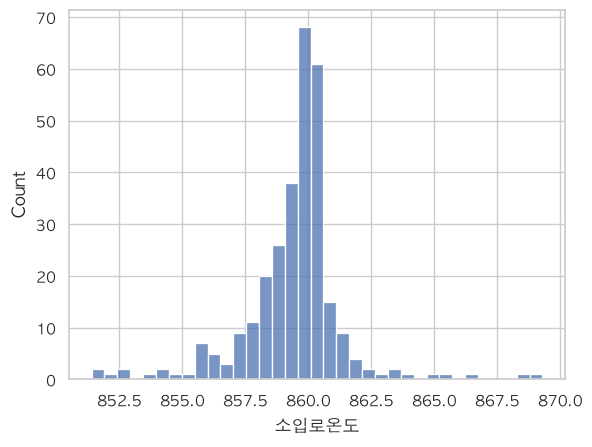

In [70]:
sns.histplot(
    data = df,
    x = "소입로온도"
)
plt.show()

## 실습 1. 첫 분포 그래프 그리기
### 목표
histplot으로 한 센서의 분포를 그리고 완성
### 단계
- data와 x에 볼 컬럼을 지정해 histplot 그리기
- 제목과 가로·세로축 이름 달기
- 값이 어디에 몰려 있는지 분포 모양 확인
### 예상 결과
전류값이 몰린 구간을 보여 주는 종 모양 분포

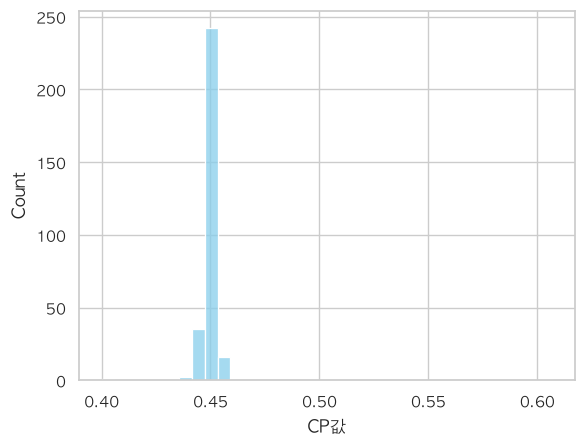

In [71]:
sns.histplot(data=df, x = "CP값",
             color="skyblue")
plt.show()

## 실습 2. bins·kde 조절
### 목표
bins로 구간 수를, kde로 분포 곡선을 조절
### 단계
- bins 값을 여러 개로 바꿔 가며 분포 그리기
- 구간 수에 따라 막대가 굵어지고 잘게 나뉘는 변화 관찰
- kde 곡선을 더해 분포 모양을 부드럽게 확인
### 예상 결과
bins 10·20·40에 따른 전류 분포 모양 차이

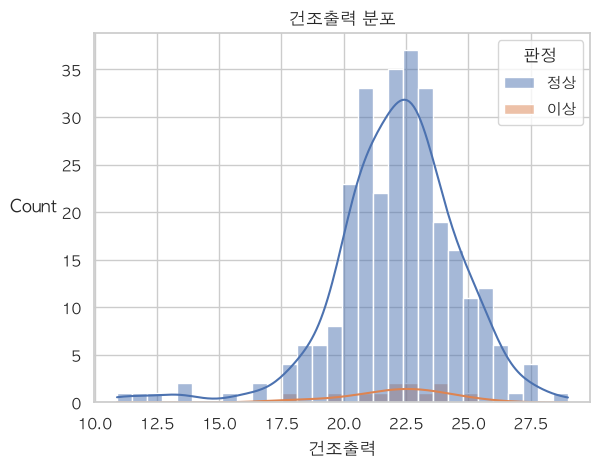

In [72]:
sns.histplot(data= df, 
             x="건조출력", 
             bins=30, 
             hue = "판정",
             kde = True,
             color = "lightpink")
plt.title("건조출력 분포")
plt.xlabel("건조출력")
plt.ylabel("Count", rotation = 0, labelpad=20)
plt.show()

## 실습 3. 양품·불량 분포 비교
### 목표
hue로 판정별 분포를 색으로 겹쳐 비교
### 단계
- x에 온도, hue에 판정을 지정해 histplot 그리기
- kde를 더해 두 그룹의 분포 모양 비교
- 불량이 어느 쪽으로 치우쳤는지 확인
### 예상 결과
양품·불량 온도 분포가 색으로 겹쳐 표시

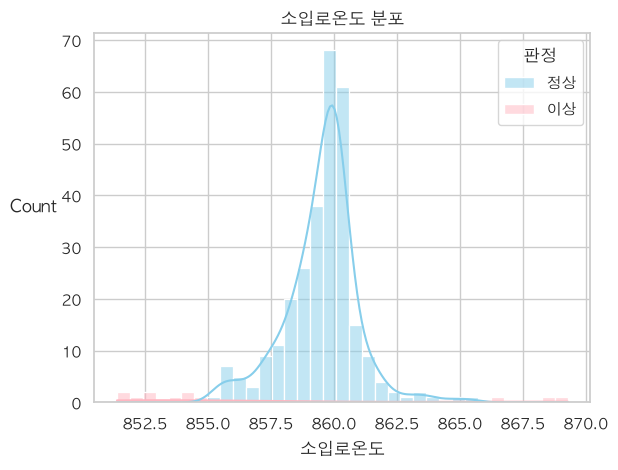

In [73]:
sns.histplot(data = df, 
             x="소입로온도", 
             hue = "판정",
             kde = True,
             palette = ["skyblue","lightpink"])
plt.title("소입로온도 분포")
plt.xlabel("소입로온도")
plt.ylabel("Count", rotation = 0, labelpad=20)
plt.show()

## 실습 4. 여러 센서 분포 한눈에 보기
### 목표
반복문으로 여러 센서의 분포를 차례로 그려 비교
### 단계
- 컬럼과 단위 목록을 반복하며 각 센서 분포 그리기
- 각 그래프에 컬럼 이름과 단위로 제목·축 달기
- 센서마다 값이 몰린 정상 범위를 정리
### 예상 결과
온도·진동·전류 분포를 차례로 확인

Index(['라인', '소입로온도', '제어출력', '건조출력', '세정기', 'CP값', '판정'], dtype='str')


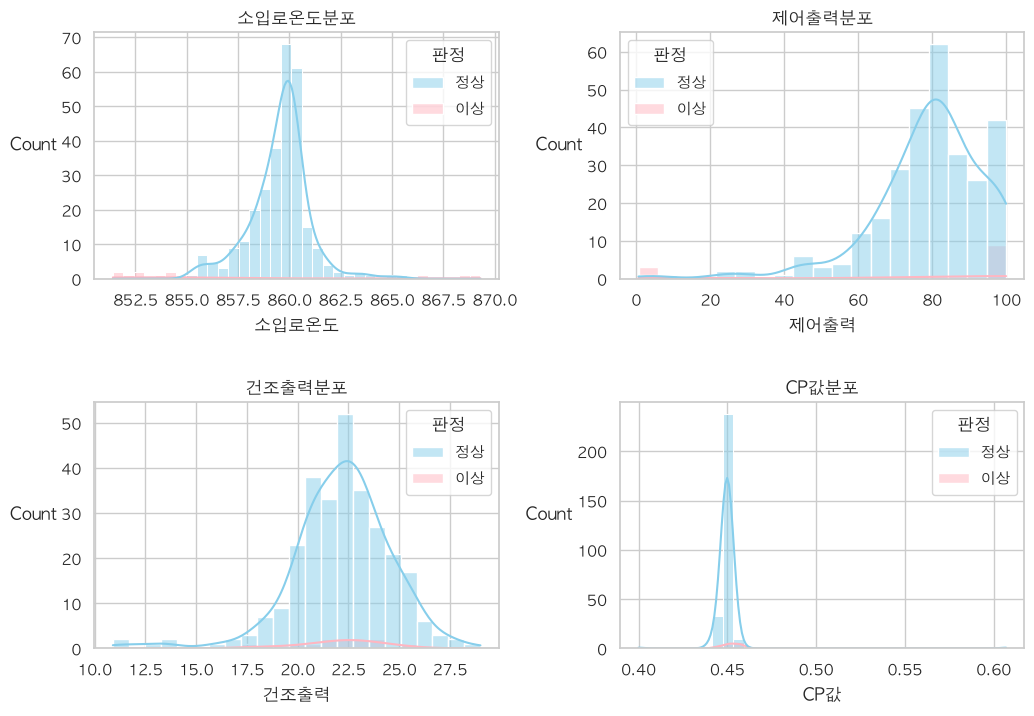

In [74]:
print(df.columns)

col = ['소입로온도', '제어출력', '건조출력','CP값']

plt.figure(figsize=(12,8))
plt.subplots_adjust(wspace=0.3, hspace=0.5) # 간격조정

for i in range(4):
    plt.subplot(2, 2, i+1)
    sns.histplot(data = df, 
         x=col[i], 
         hue = "판정",
         kde = True,
         palette = ["skyblue","lightpink"])
    plt.title(col[i]+"분포")
    plt.xlabel(col[i])
    plt.ylabel("Count", rotation = 0, labelpad=20)

plt.show()

## 실습 5. 단일 센서 박스플롯
### 목표
boxplot으로 한 센서의 사분위수와 이상치 확인
### 단계
- y에 볼 센서를 지정해 박스플롯 그리기
- 상자(가운데 절반)와 수염, 이상치 점 위치 확인
- 제목·축 이름 붙이기
### 예상 결과
전류의 상자·수염과 위쪽 이상치 점

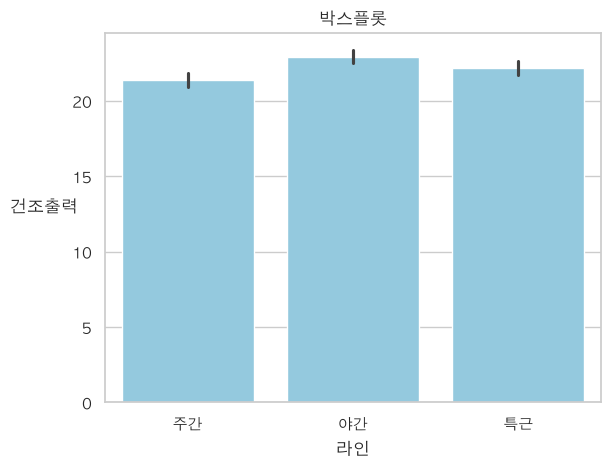

In [75]:
sns.barplot(data = df, 
             x = "라인",
             y = "건조출력",
             color = "skyblue")
plt.title("박스플롯")
plt.xlabel("라인")
plt.ylabel("건조출력", rotation = 0, labelpad=20)
plt.show()

## 실습 6. 범주별 박스플롯 비교
### 목표
x에 범주를, hue에 판정을 더해 범주별 분포 비교
### 단계
- x에 설비라인을 지정해 라인별 상자를 나란히 그리기
- hue에 판정을 더해 라인마다 양품·불량 상자 비교
- 일관된 패턴이 신뢰할 신호임을 확인
### 예상 결과
라인별 온도 상자, 그리고 라인×판정 교차 비교

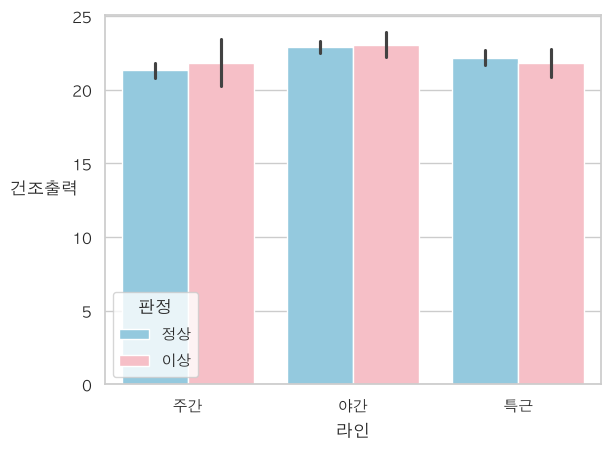

In [76]:
sns.barplot(data = df,
            x = "라인",
            y = "건조출력",
            hue = "판정",
            palette = ["skyblue","lightpink"])
plt.xlabel("라인")
plt.ylabel("건조출력", rotation = 0, labelpad=20)
plt.show()

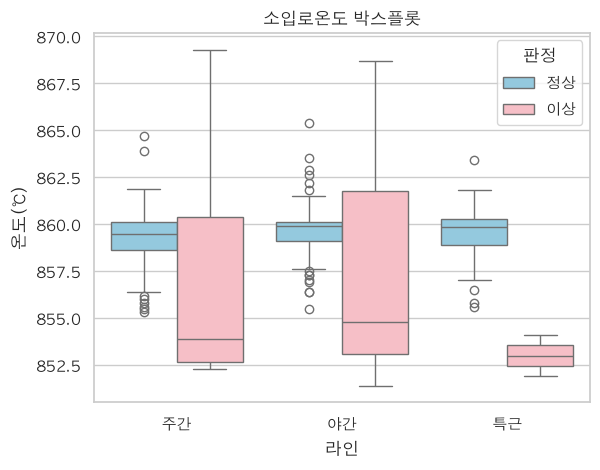

In [77]:
sns.boxplot(data=df, x='라인', y='소입로온도', hue='판정', palette = ["skyblue","lightpink"])
plt.title('소입로온도 박스플롯')
plt.ylabel('온도(℃)')
plt.show()

## 실습 7. countplot·barplot
### 목표
개수는 countplot, 평균은 barplot으로 범주 비교
### 단계
- countplot으로 라인별 데이터 개수를 막대로 세기
- barplot으로 라인별 평균 전류를 막대로 비교
- 색은 hue와 palette로 지정(범례는 끄기)
### 예상 결과
라인별 개수와 라인별 평균 전류 막대

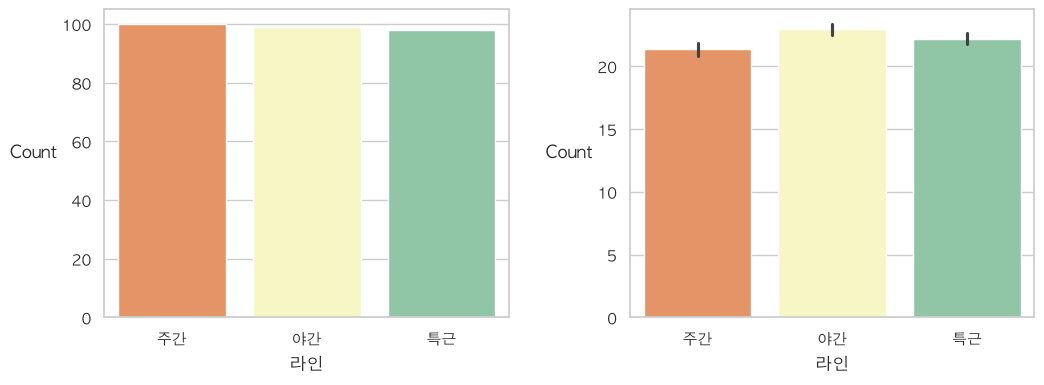

In [78]:
plt.figure(figsize=(12,4))
plt.subplots_adjust(wspace=0.3) # 간격조정

plt.subplot(1,2,1)
sns.countplot(data=df,
              x="라인",
              hue = "라인",
              palette="Spectral",
              legend=False
              )
plt.xlabel("라인")
plt.ylabel("Count", rotation = 0, labelpad=20)

plt.subplot(1,2,2)
sns.barplot(data=df,
              x="라인",
              y='건조출력',
              hue = "라인",
              palette="Spectral",
              legend=False
              )
plt.xlabel("라인")
plt.ylabel("Count", rotation = 0, labelpad=20)


plt.show()

## 실습 8. 라인별 불량 비율 비교
### 목표
라인별 양품·불량 개수를 그래프와 표로 정리
### 단계
- countplot에 hue로 판정을 넣어 라인별 양품·불량 개수 비교
- 불량이 상대적으로 많은 라인 확인
### 예상 결과
라인별 양품·불량 막대와 개수 표(A라인 불량 30 등)

Text(0, 0.5, 'Count')

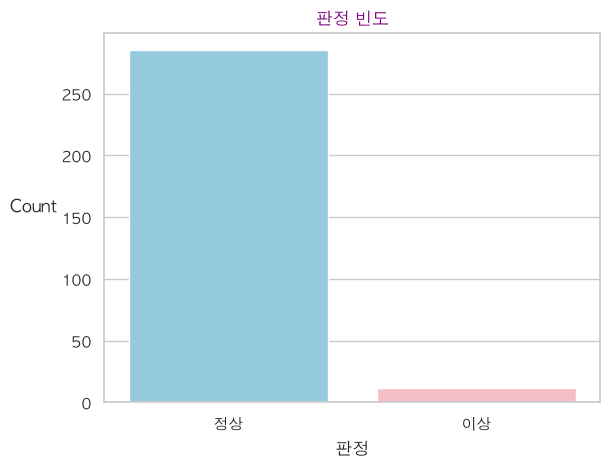

In [79]:
sns.countplot(data=df,
              x="판정",
              hue="판정",
              palette = ["skyblue","lightpink"]
              )
plt.title("판정 빈도", color = "purple")
plt.xlabel("판정")
plt.ylabel("Count", rotation = 0, labelpad=20)

## 실습 1. 산점도로 두 변수 관계 보기
### 목표
scatterplot으로 두 센서의 관계를 점으로 확인
### 단계
- x·y에 두 센서를 지정해 산점도 그리기
- alpha로 겹친 점을 반투명 처리
- 제목·축 이름을 붙이고 관계 방향 읽기
### 예상 결과
온도가 오를 때 압력이 낮아지는 음의 관계 경향

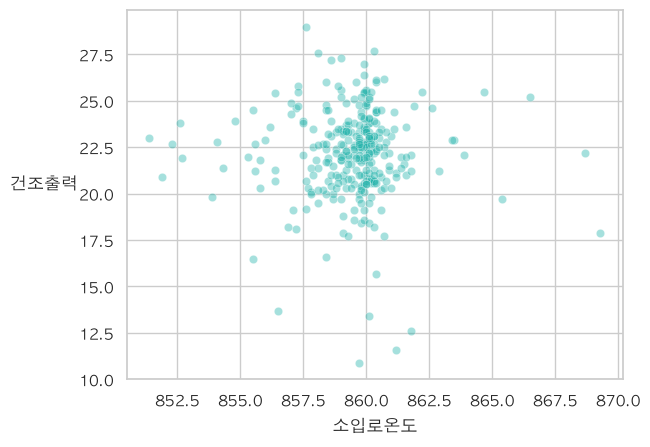

In [80]:
sns.scatterplot(data = df,
                x = "소입로온도",
                y = "건조출력",
                alpha = 0.4,
                color = "lightseagreen"
                )
plt.xlabel("소입로온도")
plt.ylabel("건조출력", rotation = 0, labelpad=25)
plt.show()

## 실습 2. 판정별 산점도 패턴
### 목표
hue로 양품·불량을 색으로 구분해 위험 영역 찾기
### 단계
- x·y에 두 센서, hue에 판정을 지정
- 산점도에서 불량 점이 몰린 영역 확인
- 어느 영역이 위험 영역인지 해석
### 예상 결과
불량 점이 온도·전류가 함께 높은 영역에 모임

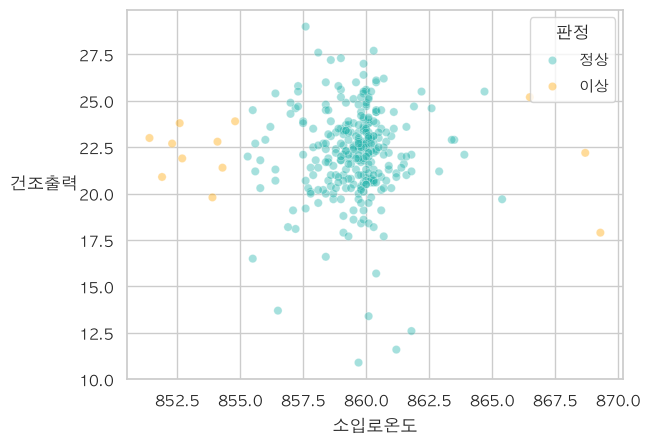

In [81]:
sns.scatterplot(data = df,
                x = "소입로온도",
                y = "건조출력",
                alpha = 0.4,
                palette=  ["lightseagreen", "orange"],
                hue = "판정"
                )
plt.xlabel("소입로온도")
plt.ylabel("건조출력", rotation = 0, labelpad=25)
plt.show()

In [82]:
corr = df.corr(numeric_only=True)
print(corr.round(2))

print(f"소입로온도-제어출력 상관관계 : {df["소입로온도"].corr(df["제어출력"]).round(2)}")

       소입로온도  제어출력  건조출력   세정기   CP값
소입로온도   1.00 -0.74 -0.01  0.03 -0.03
제어출력   -0.74  1.00  0.09 -0.02  0.01
건조출력   -0.01  0.09  1.00 -0.05 -0.10
세정기     0.03 -0.02 -0.05  1.00 -0.04
CP값    -0.03  0.01 -0.10 -0.04  1.00
소입로온도-제어출력 상관관계 : -0.74


(array([0.5, 1.5, 2.5, 3.5, 4.5]),
 [Text(0, 0.5, '소입로온도'),
  Text(0, 1.5, '제어출력'),
  Text(0, 2.5, '건조출력'),
  Text(0, 3.5, '세정기'),
  Text(0, 4.5, 'CP값')])

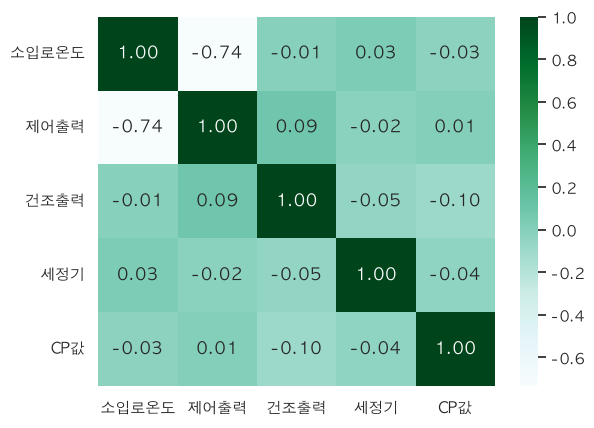

In [83]:
# 간단한 상관관계 히트맵

sns.heatmap(data=corr,
            annot = True,
            fmt = ".2f",
            cmap = "BuGn")

plt.yticks(rotation=0)


## 실습 3. 센서 상관관계 heatmap
### 목표
상관행렬을 heatmap으로 그리고 강한 관계 쌍 정리
### 단계
- corr로 숫자 컬럼끼리 상관행렬 만들기
- heatmap에 annot·cmap·center를 주어 색과 숫자로 표현
- 대각선 제외 절댓값이 큰 쌍의 상관계수 확인
### 예상 결과
온도-전류 0.51(강한 양), 온도-압력 -0.24 등

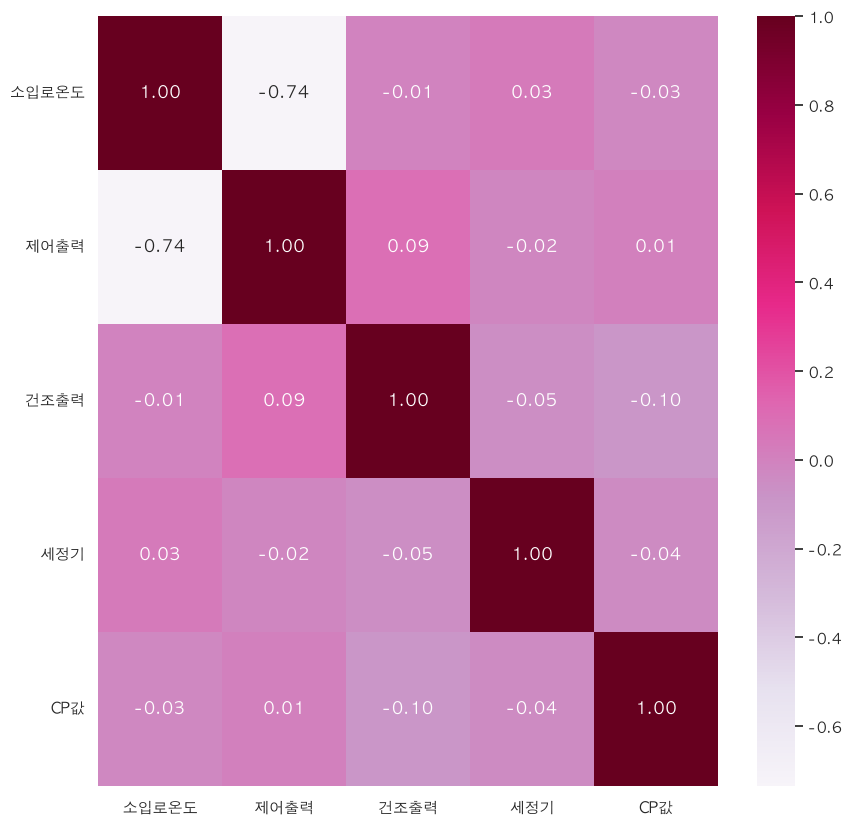

In [84]:
plt.figure(figsize=(10,10))


sns.heatmap(data = corr,
            annot=True,
            fmt = ".2f",
            cmap = "PuRd")

plt.yticks(rotation=0)

plt.show()

## 실습 4. 종합 리포트 — 분포·박스플롯
### 목표
subplots로 개수·분포·박스플롯을 한 화면에 배치
### 단계
- subplots로 가로 3칸을 만들기
- 각 칸에 라인별 개수·온도 분포·진동 박스플롯을 그리기
- 각 축에 제목을 달고 tight_layout으로 정리
### 예상 결과
개수·분포·박스플롯이 나란한 3칸 리포트

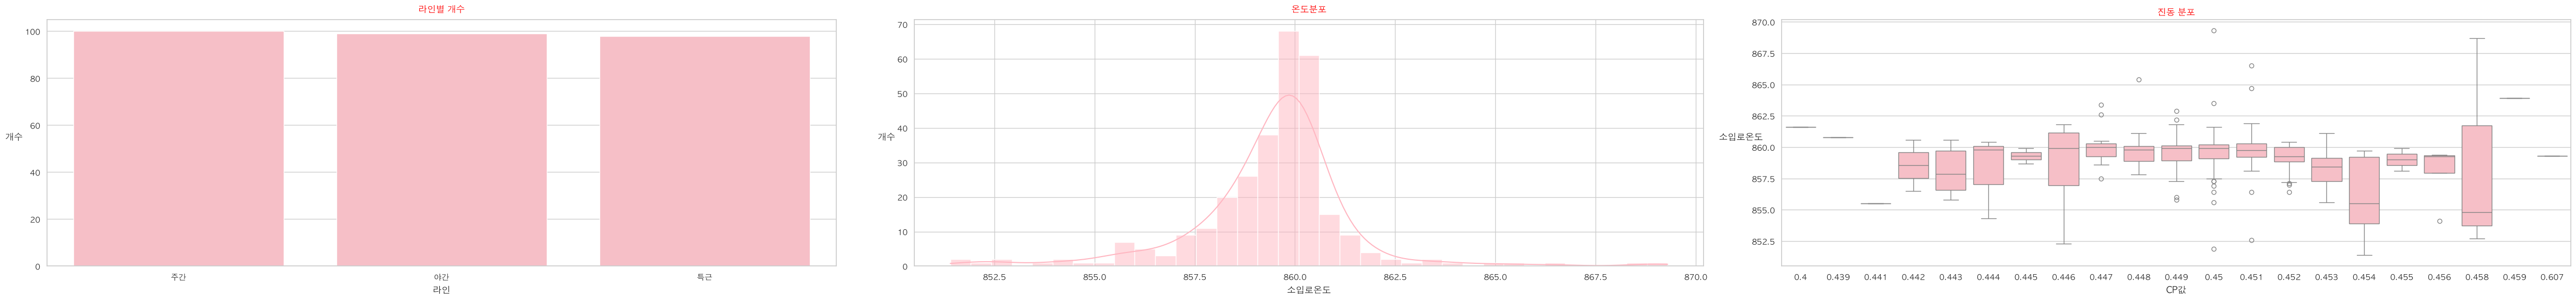

In [121]:
fig, axs = plt.subplots(1, 3, figsize=(50,6))
plt.subplots_adjust(wspace=0.3) # 간격조정

sns.countplot(data = df,
            x = "라인",
            color = "lightpink",
            ax=axs[0]
            )
axs[0].set_title("라인별 개수", color = "Red", pad=10)
axs[0].set_ylabel("개수", rotation=0, labelpad=15)

sns.histplot(data = df,
            x = "소입로온도",
            color = "lightpink",
            kde = True,
            ax=axs[1]
            )
axs[1].set_title("온도분포", color = "Red", pad=10)
axs[1].set_ylabel("개수", rotation=0, labelpad=15)

sns.boxplot(data = df,
            x = "CP값",
            y = "소입로온도",
            color = "lightpink",
            ax=axs[2]
            )
axs[2].set_title("진동 분포", color = "Red")
axs[2].set_ylabel("소입로온도", rotation=0, labelpad=15)
plt.tight_layout()

plt.show()

## 실습 5. 종합 리포트 — 산점도·heatmap
### 목표
subplots로 산점도와 상관 heatmap을 한 화면에 배치
### 단계
- subplots로 가로 2칸을 만들기
- 왼쪽에 판정별 산점도, 오른쪽에 상관 heatmap 그리기
- 각 축에 제목을 달고 tight_layout으로 정리
### 예상 결과
판정별 산점도와 상관 heatmap이 나란한 리포트

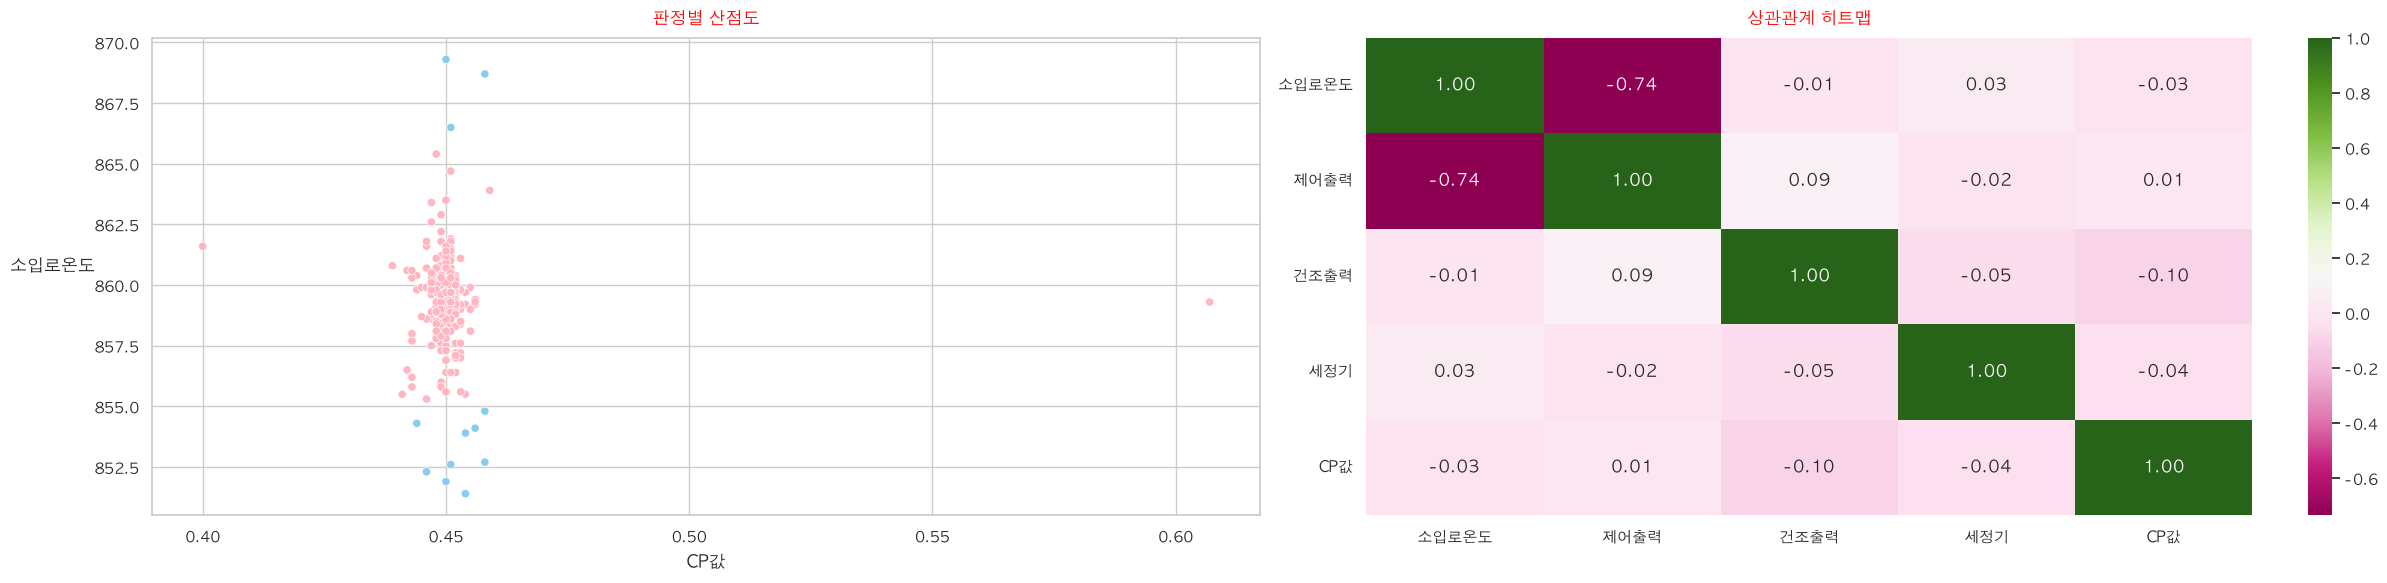

In [126]:
fig, axs = plt.subplots(1, 2, figsize=(25,6))
plt.subplots_adjust(wspace=0.3) # 간격조정

sns.scatterplot(data = df,
            x = "CP값",
            y = "소입로온도",
            hue = "판정",
            palette = ["lightpink", "skyblue"],
            legend=False,
            ax=axs[0]
            )
axs[0].set_title("판정별 산점도", color = "Red", pad=10)
axs[0].set_ylabel("소입로온도", rotation = 0, labelpad=30)


sns.heatmap(data = corr,
            ax=axs[1],
            annot=True,
            fmt = ".2f",
            cmap="PiYG")
axs[1].set_title("상관관계 히트맵", color = "Red", pad=10)
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

## 실습 6. 시각화 리포트 통합·저장
### 목표
핵심 그래프 4개를 2×2로 모아 리포트 파일로 저장
### 단계
- subplots로 2×2 격자를 만들기
- 분포·박스플롯·산점도·heatmap을 네 칸에 배치
- savefig로 리포트를 이미지 파일로 저장(show보다 먼저)
### 예상 결과
분포·박스·관계·상관을 담은 2×2 리포트 저장

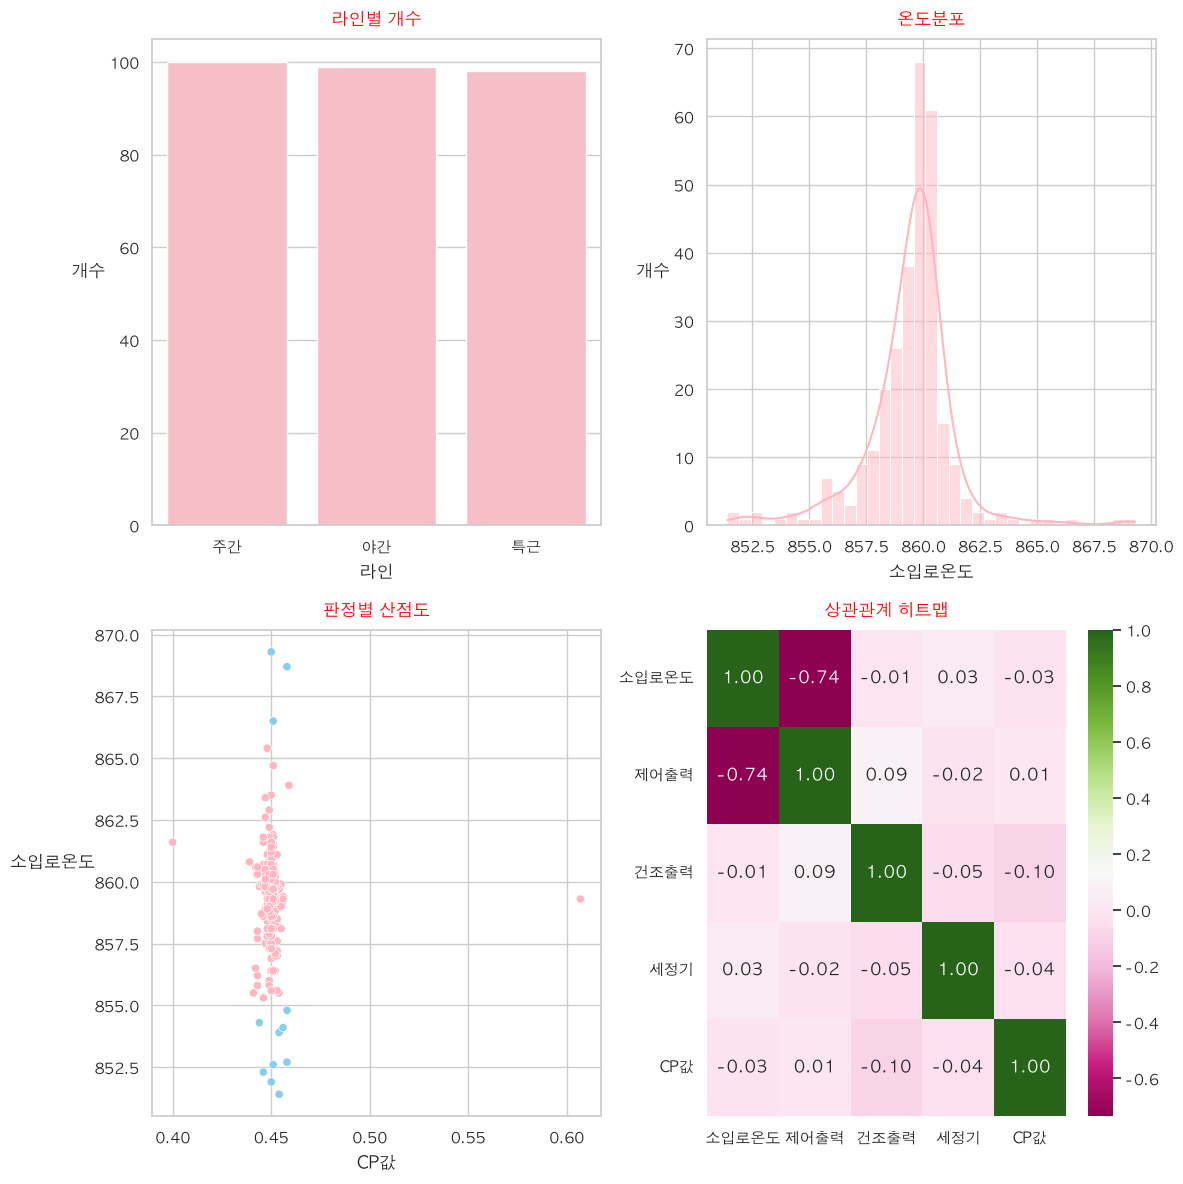

In [130]:
fig, axs = plt.subplots(2, 2, figsize=(12,12))
plt.subplots_adjust(wspace=0.3, hspace=0.5) # 간격조정

sns.countplot(data = df,
            x = "라인",
            color = "lightpink",
            ax=axs[0][0]
            )
axs[0][0].set_title("라인별 개수", color = "Red", pad=10)
axs[0][0].set_ylabel("개수", rotation=0, labelpad=15)

sns.histplot(data = df,
            x = "소입로온도",
            color = "lightpink",
            kde = True,
            ax=axs[0][1]
            )
axs[0][1].set_title("온도분포", color = "Red", pad=10)
axs[0][1].set_ylabel("개수", rotation=0, labelpad=15)

sns.scatterplot(data = df,
            x = "CP값",
            y = "소입로온도",
            hue = "판정",
            palette = ["lightpink", "skyblue"],
            legend=False,
            ax=axs[1][0]
            )
axs[1][0].set_title("판정별 산점도", color = "Red", pad=10)
axs[1][0].set_ylabel("소입로온도", rotation = 0, labelpad=30)


sns.heatmap(data = corr,
            ax=axs[1][1],
            annot=True,
            fmt = ".2f",
            cmap="PiYG")
axs[1][1].set_title("상관관계 히트맵", color = "Red", pad=10)
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig("리포트.png", dpi=150, bbox_inches="tight")

plt.show()